<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_049_early_stopping_boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 49/365 — Early Stopping in Boosting
## How does a boosting model know when to stop adding trees?

Yesterday we explored **XGBoost** and saw that training loss can keep falling even when validation performance stops improving.

Today we turn that into a practical technique:

**Early Stopping**

The idea:
1. Train boosting rounds one by one.
2. Monitor a validation metric.
3. Stop when validation performance has not improved for several rounds.
4. Keep the best iteration.

This can reduce wasted computation and help control overfitting.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss

try:
    from xgboost import XGBClassifier
except ImportError:
    raise ImportError("Install XGBoost once with: pip install xgboost")


## 1. Load the real Breast Cancer Wisconsin dataset


In [2]:
data=load_breast_cancer(as_frame=True)
X=data.data
y=data.target

X_trainval,X_test,y_trainval,y_test=train_test_split(
    X,y,test_size=0.20,random_state=42,stratify=y
)

X_train,X_val,y_train,y_val=train_test_split(
    X_trainval,y_trainval,test_size=0.25,random_state=42,stratify=y_trainval
)

print("Train:",X_train.shape)
print("Validation:",X_val.shape)
print("Test:",X_test.shape)


Train: (341, 30)
Validation: (114, 30)
Test: (114, 30)


## 2. Why three splits?

- **Training set** teaches the model.
- **Validation set** decides when to stop.
- **Test set** stays untouched until the end.

This prevents us from choosing the stopping point using the final test data.


## 3. Train XGBoost with Early Stopping


In [3]:
model=XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    eval_metric="logloss",
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train,y_train),(X_val,y_val)],
    verbose=False
)

print("Best iteration:",model.best_iteration)
print("Best validation score:",model.best_score)


Best iteration: 323
Best validation score: 0.10982757649310913


## 4. Visualize training vs validation loss


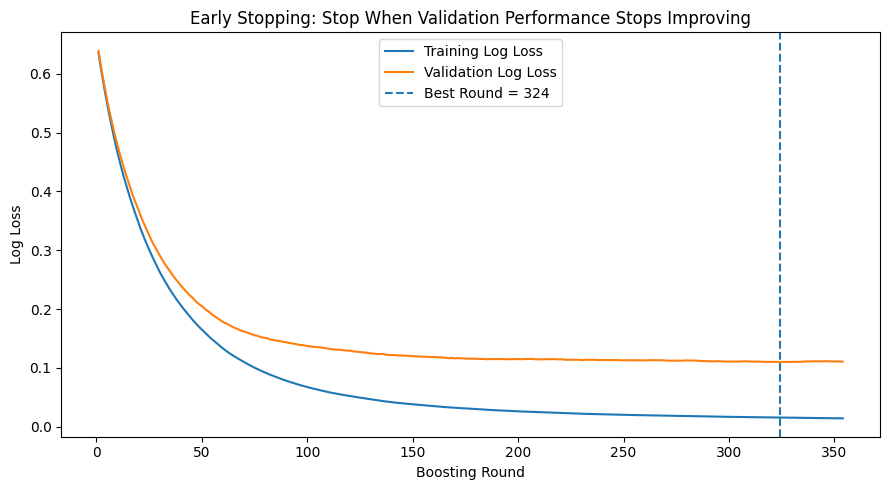

In [4]:
history=model.evals_result()
train_loss=history["validation_0"]["logloss"]
val_loss=history["validation_1"]["logloss"]
rounds=np.arange(1,len(train_loss)+1)
best_round=model.best_iteration+1

plt.figure(figsize=(9,5))
plt.plot(rounds,train_loss,label="Training Log Loss")
plt.plot(rounds,val_loss,label="Validation Log Loss")
plt.axvline(best_round,linestyle="--",label=f"Best Round = {best_round}")
plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")
plt.title("Early Stopping: Stop When Validation Performance Stops Improving")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Final evaluation on the untouched test set


In [5]:
test_pred=model.predict(X_test)
test_prob=model.predict_proba(X_test)
print("Final Test Accuracy:",round(accuracy_score(y_test,test_pred),3))
print("Final Test Log Loss:",round(log_loss(y_test,test_prob),3))


Final Test Accuracy: 0.947
Final Test Log Loss: 0.111


## Enterprise intuition

Imagine a fraud or credit-risk model with:

`n_estimators = 5000`

If validation performance stops improving around tree 240, building thousands of additional trees may:

- waste compute
- increase training time
- increase model complexity
- potentially overfit

Early stopping uses validation performance as a practical training control.


## What does `early_stopping_rounds = 30` mean?

It means:

> Stop if the validation metric fails to improve for 30 consecutive boosting rounds.

The model still remembers the **best iteration** seen before stopping.


## What does this experiment teach?

- Training loss can keep improving even when validation performance stops improving.
- Early stopping monitors validation performance during training.
- `n_estimators` can be treated as a maximum budget rather than a number that must always be fully used.
- The final test set should not be used to choose the stopping point.
- Early stopping can save compute and reduce unnecessary model complexity.

> **The question is not “How many trees can I train?” It is “After which tree does validation performance stop getting better?”**


## References

- https://xgboost.readthedocs.io/en/stable/python/python_api.html
- https://xgboost.readthedocs.io/en/stable/parameter.html
- https://xgboost.readthedocs.io/en/stable/python/examples/index.html
- https://arxiv.org/abs/1603.02754
